In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from sklearn.datasets import fetch_openml

# Stylesheet
CATEGORICAL = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
SEQUENTIAL_BLUE = LinearSegmentedColormap.from_list(
    "seq_blue", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"]
)
DIVERGING_BLUE_RED = LinearSegmentedColormap.from_list(
    "div_blue_red", ["#184f95", "#f0efec", "#e34948"]
)
STATUS = {
    "good": "#0ca30c",
    "warning": "#fab219",
    "serious": "#ec835a",
    "critical": "#d03b3b",
}
INK, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"


def set_plot_style():
    sns.set_theme(style="white")
    mpl.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": INK_MUTED,
        "axes.labelcolor": INK_SECONDARY,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 1,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "text.color": INK,
        "font.family": "sans-serif",
        "legend.frameon": False,
        "axes.prop_cycle": mpl.cycler(color=CATEGORICAL),
    })


set_plot_style()

# Daten laden und Speicher optimieren
dataset = fetch_openml(data_id=45566, as_frame=True)
X = dataset.data.astype("float32")  # Projekthinweis umgesetzt[cite: 1]
y = dataset.target.cat.codes.astype("int8")

df = X.copy()
df["target"] = y

## Balkendiagramm

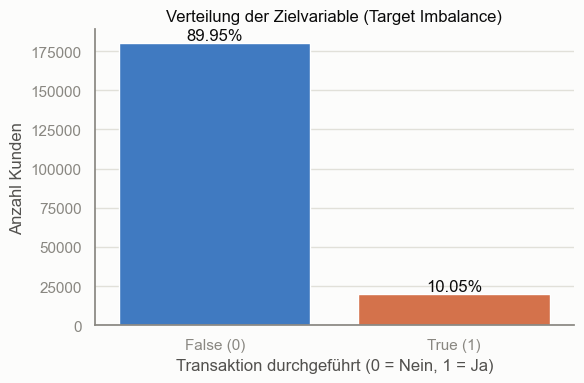

In [ ]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(x="target", hue="target", data=df, legend=False)

plt.title("Verteilung der Zielvariable (Target Imbalance)")
plt.xlabel("Transaktion durchgeführt (0 = Nein, 1 = Ja)")
plt.ylabel("Anzahl Kunden")
plt.xticks([0, 1], ["False (0)", "True (1)"])

total = len(df)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        percentage = f"{100 * height / total:.2f}%"
        ax.annotate(
            percentage,
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            color=INK,
        )

plt.tight_layout()
plt.show()

Die Analyse der Zielvariable zeigt eine deutliche Klassenimbalance. Nur **10,05 %** der Fälle gehören zur Positivklasse, während **89,95 %** der Negativklasse zugeordnet sind. Aufgrund dieser ungleichen Verteilung ist die **Accuracy** als alleinige Bewertungsmetrik nur wenig aussagekräftig. Ein Modell, das ausschließlich die Negativklasse vorhersagt, würde bereits eine Accuracy von rund **90 %** erreichen.

Für die Bewertung der Modelle wird daher insbesondere die **Area Under the ROC Curve (ROC-AUC)** verwendet. Bei der Kreuzvalidierung wird zudem ein **Stratified K-Fold-Verfahren** eingesetzt, damit das Verhältnis zwischen Positiv- und Negativklasse in den einzelnen Teilmengen möglichst erhalten bleibt.


## Horizontales Balkendiagramm

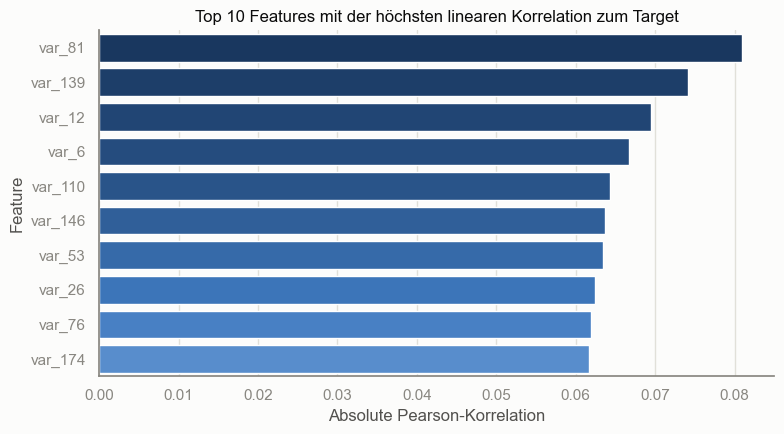

In [ ]:

df["target"] = df["target"].astype(int)

corr = df.corr()
top_corr = (
    corr["target"].drop("target").abs().sort_values(ascending=False).head(10)
)

plt.figure(figsize=(8, 4.5))

palette_top10 = SEQUENTIAL_BLUE(np.linspace(0.4, 1, 10))[::-1].tolist()

sns.barplot(
    x=top_corr.values,
    y=top_corr.index,
    hue=top_corr.index,
    palette=palette_top10,
    legend=False,
)

plt.title("Top 10 Features mit der höchsten linearen Korrelation zum Target")
plt.xlabel("Absolute Pearson-Korrelation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

Die Betrachtung der linearen Zusammenhänge zwischen den Eingabemerkmalen und der Zielvariable macht deutlich, dass selbst die stärksten Prädiktoren nur sehr schwache Korrelationen aufweisen. Das Merkmal var_81 zeigt mit einem Wert von knapp über 0,08 die höchste absolute Pearson-Korrelation, gefolgt von var_139 und var_12. Da kein einzelnes Feature eine dominante lineare Trennschärfe besitzt, wird ersichtlich, dass einfache lineare Modelle unzureichend sind und baumbasierte Ensemble-Methoden eingesetzt werden müssen, um die komplexen Zusammenhänge zu erfassen.

## KDE-Plots / Kernel Density Estimation

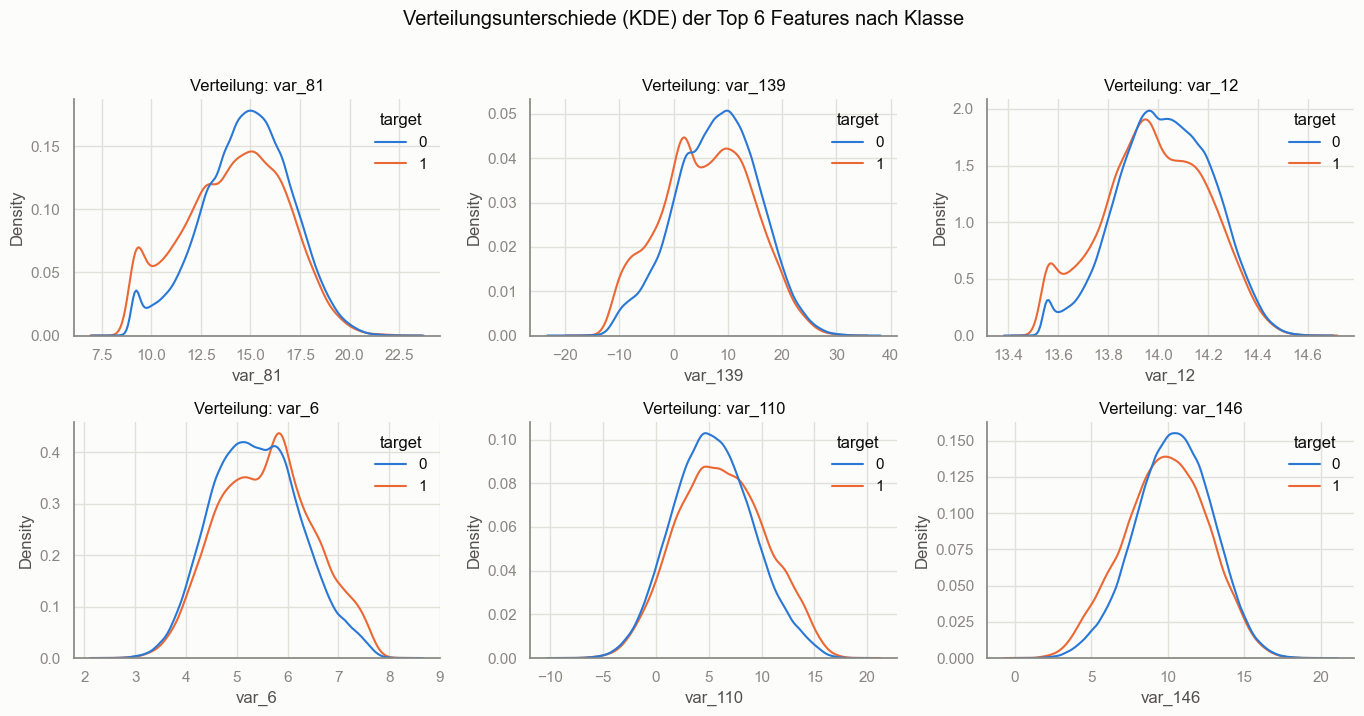

In [ ]:
top_6_features = top_corr.head(6).index

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(top_6_features):
    sns.kdeplot(data=df, x=col, hue="target", ax=axes[i], common_norm=False)
    axes[i].set_title(f"Verteilung: {col}")

plt.suptitle(
    "Verteilungsunterschiede (KDE) der Top 6 Features nach Klasse", y=1.02
)
plt.tight_layout()
plt.show()

Die Kernel-Density-Estimation-Plots (KDE) der sechs korreliertesten Merkmale veranschaulichen die Dichteverteilungen getrennt nach den beiden Zielklassen. Es zeigen sich feine, aber systematische Abweichungen im Verteilungsverlauf. Insbesondere bei var_81 und var_12 weisen die Werte für Klasse 1 im unteren Wertebereich höhere Dichten auf als für Klasse 0. Zudem lassen sich bimodal-ähnliche Höckerstrukturen erkennen, was darauf hindeutet, dass nicht-lineare Entscheidungsbäume diese lokalen Verteilungsunterschiede effektiv zur Klassentrennung nutzen können.

## Korrelations-Heatmap

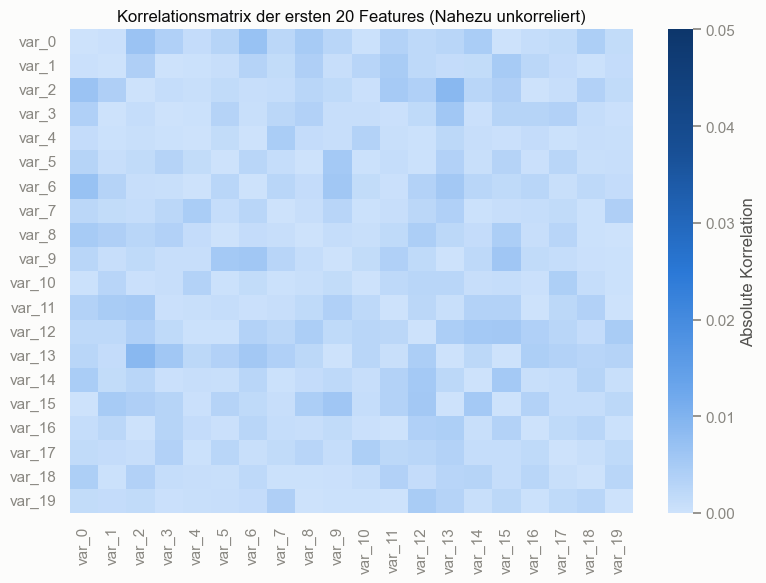

In [ ]:
feature_corr = X.corr().abs()
mask_diag = 1 - np.eye(feature_corr.shape[0])
feature_corr_no_diag = feature_corr * mask_diag

plt.figure(figsize=(8, 6))

sns.heatmap(
    feature_corr_no_diag.iloc[:20, :20],
    cmap=SEQUENTIAL_BLUE,
    vmin=0,
    vmax=0.05,
    cbar_kws={"label": "Absolute Korrelation"},
)

plt.title("Korrelationsmatrix der ersten 20 Features (Nahezu unkorreliert)")
plt.tight_layout()
plt.show()

Die Heatmap der paarweisen Korrelationen zwischen den Merkmalen belegt eine nahezu vollständige Unabhängigkeit der Features untereinander. Alle berechneten Korrelationswerte bewegen sich nahe der Nulllinie (maximal 0,02). Dies bestätigt die synthetische Struktur des Kaggle-Datensatzes und zeigt, dass keinerlei Multikollinearität vorliegt. Ein Filtern von redudanten Variablen ist somit nicht erforderlich, da jedes Feature eigenständige Informationen liefert.

## Histogramm

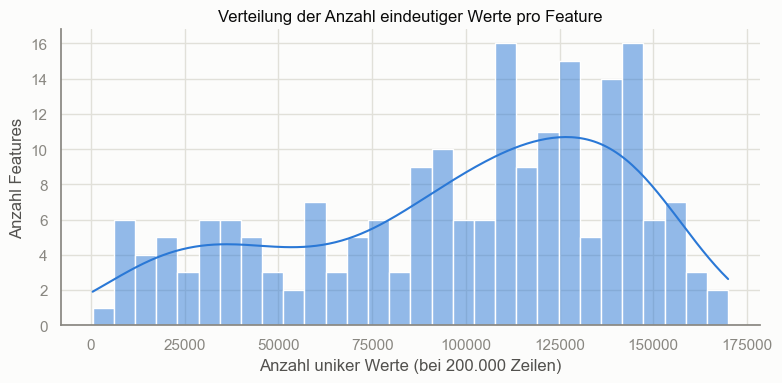

In [ ]:
unique_counts = X.nunique()

plt.figure(figsize=(8, 4))
sns.histplot(unique_counts, bins=30, kde=True, color=CATEGORICAL[0])

plt.title("Verteilung der Anzahl eindeutiger Werte pro Feature")
plt.xlabel("Anzahl uniker Werte (bei 200.000 Zeilen)")
plt.ylabel("Anzahl Features")

plt.tight_layout()
plt.show()

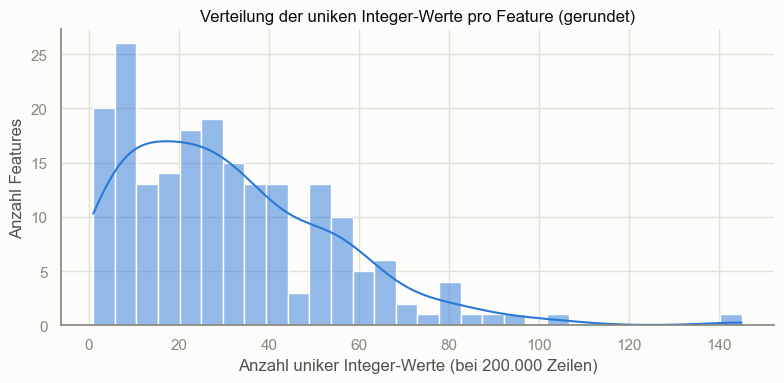

In [ ]:

if "X" not in locals():
    from sklearn.datasets import fetch_openml

    dataset = fetch_openml(data_id=45566, as_frame=True)
    X = dataset.data.astype("float32")

bar_color = CATEGORICAL[0] if "CATEGORICAL" in locals() else "#2a78d6"

X_int = X.round().astype(int)
unique_counts_int = X_int.nunique()

# Plot erstellen
plt.figure(figsize=(8, 4))
sns.histplot(unique_counts_int, bins=30, kde=True, color=bar_color)

plt.title("Verteilung der uniken Integer-Werte pro Feature (gerundet)")
plt.xlabel("Anzahl uniker Integer-Werte (bei 200.000 Zeilen)")
plt.ylabel("Anzahl Features")

plt.tight_layout()
plt.show()

Das Histogramm über die Anzahl uniker Werte pro Spalte offenbart ein zentrales Charakteristikum des Datensatzes: Trotz eines Stichprobenumfangs von 200.000 Beobachtungen erreicht kein Feature eine entsprechende Anzahl an eindeutigen Werten. Viele Variablen weisen deutlich unter 100.000 unike Werte auf, was auf eine hohe Frequenz exakt identischer Werte hindeutet. Dieses Verhalten spricht für das Vorhandensein von Mehrfachwerten und liefert die theoretische Grundlage für die spätere Erstellung von Frequenz-Features (Count Encoding).

Begründung für unterschiedliche Histogramme: Bei den kontinuierlichen Float-Daten besitzt die Mehrheit der Features aufgrund hoher Präzision viele unike Werte (linksschiefe Verteilung der uniken Counts). Durch die Rundung auf Integers werden nahe beieinanderliegende Werte stark aggregiert. Dadurch reduziert sich die Anzahl uniker Werte pro Spalte drastisch auf unter 150, wodurch die Verteilung rechtsschief wird und die meiste Dichte bei wenigen uniken Ganzzahlen liegt

## Scatterplot nach PCA

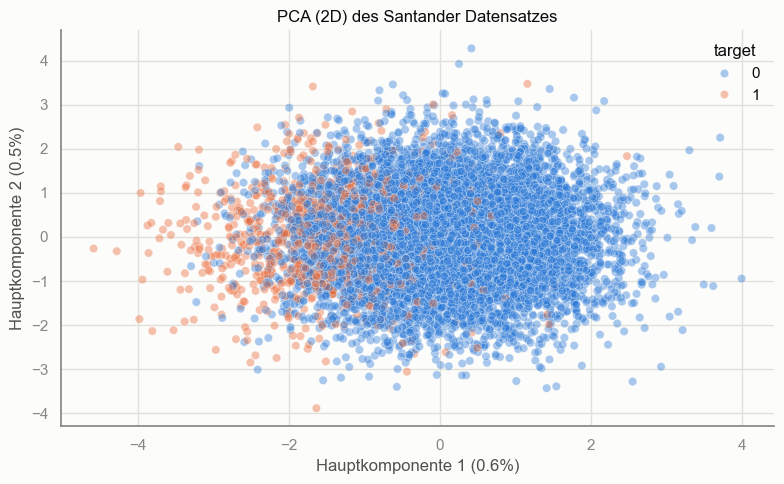

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca_result = pca.fit_transform(X_scaled)
var_ratio = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca_result, columns=["PC1", "PC2"])
pca_df["target"] = df["target"].values

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=pca_df.sample(10000, random_state=42),
    x="PC1",
    y="PC2",
    hue="target",
    alpha=0.4,
)

plt.title("PCA (2D) des Santander Datensatzes")
plt.xlabel(f"Hauptkomponente 1 ({var_ratio[0]*100:.1f}%)")
plt.ylabel(f"Hauptkomponente 2 ({var_ratio[1]*100:.1f}%)")

plt.tight_layout()
plt.show()

Die zweidimensionale Hauptkomponentenanalyse (PCA) führt zu einer vollständig überlappenden Punktwolke, in der die beiden Zielklassen nicht linear voneinander getrennt werden können. Die ersten beiden Hauptkomponenten erklären zusammen lediglich 1,1 % der Gesamtvarianz der Daten (PC1: 0,6 %, PC2: 0,5 %). Dies untermauert, dass sich die Informationsgehalt gleichmäßig über den gesamten 200-dimensionalen Raum verteilt und klassische Verfahren zur linearen Dimensionsreduktion ungeeignet sind.

In [ ]:
import pandas as pd
from sklearn.datasets import fetch_openml

dataset = fetch_openml(data_id=45566, as_frame=True)

df = dataset.data.astype("float32").copy()
df.insert(0, "target", dataset.target.cat.codes.astype("int8"))

df.to_parquet("santander_cleaned.parquet", index=False)
print("Datei 'santander_cleaned.parquet' erfolgreich gespeichert!")

Datei 'santander_cleaned.parquet' erfolgreich gespeichert!
